# Notebook 12 – Feature Relationships

# Topic 1 – Correlation Matrix

## Step 1 – Understand the Concept

A correlation matrix is a table that shows the correlation between multiple numerical variables.

Correlation measures the strength and direction of a relationship between two variables.

The Pearson correlation coefficient ranges from -1 to +1.

- +1 → Perfect positive linear relationship
- 0 → No linear relationship
- -1 → Perfect negative linear relationship

**Formula:**

r = Cov(X, Y) / (σX × σY)

Where:

- Cov(X, Y) = Covariance between X and Y
- σX = Standard deviation of X
- σY = Standard deviation of Y

A correlation matrix calculates this relationship for every pair of selected numerical features.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose we study:

- Hours studied
- Exam marks
- Attendance

Students who study more hours may generally obtain higher marks.

This may result in a positive correlation between study hours and marks.

### Numerical Example

Hours Studied:

1, 2, 3, 4, 5

Marks:

50, 55, 65, 72, 80

As study hours increase, marks also increase.

Therefore, the correlation is positive.

### Business Example

An e-commerce company may analyze:

- Advertising expenditure
- Website visitors
- Sales

The company can use a correlation matrix to understand relationships among these numerical variables.

### AI/ML Example

Before training a Machine Learning model, a correlation matrix can help identify highly correlated numerical features.

For example:

house_area and number_of_rooms may have a strong positive correlation.

This information can be useful during feature analysis and selection.


## Step 3 – Implement the Concept

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    "Study_Hours": [1, 2, 3, 4, 5, 6],
    "Attendance": [60, 65, 70, 75, 80, 85],
    "Marks": [50, 55, 65, 72, 80, 88],
    "Sleep_Hours": [8, 7, 7, 6, 6, 5]
}

df = pd.DataFrame(data)

correlation_matrix = df.corr()

print(correlation_matrix)

             Study_Hours  Attendance     Marks  Sleep_Hours
Study_Hours     1.000000    1.000000  0.997916    -0.968330
Attendance      1.000000    1.000000  0.997916    -0.968330
Marks           0.997916    0.997916  1.000000    -0.955467
Sleep_Hours    -0.968330   -0.968330 -0.955467     1.000000


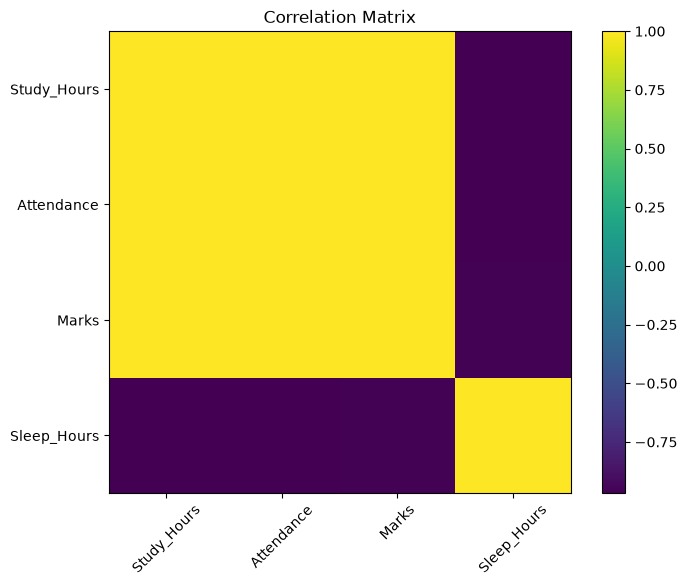

In [2]:
plt.figure(figsize=(8, 6))

plt.imshow(correlation_matrix, interpolation="nearest")
plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.show()

## Interpretation

The correlation matrix shows the correlation coefficient between every pair of numerical features.

Values closer to +1 indicate a strong positive linear relationship.

Values closer to -1 indicate a strong negative linear relationship.

Values closer to 0 indicate a weak or no linear relationship.

Correlation does not prove causation.

## Advantages

- Easy to calculate and interpret.
- Helps identify relationships between numerical features.
- Useful during Exploratory Data Analysis.
- Can help identify potentially redundant features.

## Limitations

- Pearson correlation mainly measures linear relationships.
- Correlation does not imply causation.
- It can be affected by outliers.
- It does not directly handle categorical variables.

# Topic 2 – Multicollinearity

## Step 1 – Understand the Concept

Multicollinearity occurs when two or more predictor features in a Machine Learning or statistical model are highly related to each other.

For example:

- House size
- Number of rooms
- Number of bedrooms

These variables may contain overlapping information.

Multicollinearity can make it difficult to determine the individual effect of each feature.

It is especially important in regression models because highly correlated predictors can make coefficient estimates unstable and harder to interpret.

## Step 2 – Demonstrate the Concept

### Real-World Example

Consider house price prediction.

Features:

- House area
- Number of rooms
- Number of bedrooms

Larger houses often have more rooms.

Therefore, some of these features may be strongly related.

### Numerical Example

Suppose:

House Area = [1000, 1200, 1400, 1600]

Number of Rooms = [3, 4, 5, 6]

The two variables increase together.

This indicates a strong relationship and may create multicollinearity in a regression model.

### Business Example

A company predicts sales using:

- Advertising budget
- Marketing budget
- Promotional spending

These variables may overlap heavily.

### AI/ML Example

Multicollinearity can make linear regression coefficients unstable.

The model may still predict reasonably well, but interpreting the individual coefficients becomes difficult.

## How to Identify Multicollinearity

Common approaches include:

1. Correlation Matrix
2. Variance Inflation Factor (VIF)

A very high correlation between predictor variables can indicate possible multicollinearity.

VIF provides a more model-oriented measure of how much the variance of an estimated coefficient is inflated because of relationships among predictors.

## Important Point

High correlation between two features is a warning sign, but pairwise correlation alone may miss multicollinearity involving several variables.

## Interpretation

Multicollinearity means predictor variables contain overlapping information.

It is especially important when we need to interpret regression coefficients.

Possible approaches include:

- Removing redundant features
- Combining related features
- Using regularization such as Ridge Regression
- Using domain knowledge
- Applying feature selection techniques

## Advantages of Detecting Multicollinearity

- Improves model interpretability.
- Can reduce redundant information.
- Helps identify unnecessary predictors.
- Can improve stability of some statistical models.

## Limitations

- Removing a feature may also remove useful information.
- Some Machine Learning algorithms are less affected by multicollinearity than linear regression.
- Detection does not automatically tell us which feature should be removed.

# Topic 3 – Variance Inflation Factor (VIF)

## Step 1 – Understand the Concept

Variance Inflation Factor, or VIF, is a measure used to detect multicollinearity among predictor variables.

For a feature Xᵢ:

VIFᵢ = 1 / (1 - R²ᵢ)

Where R²ᵢ is obtained by regressing feature Xᵢ against the other predictor features.

The basic interpretation is:

- VIF = 1 → No multicollinearity with the other predictors
- Higher VIF → Greater multicollinearity

A commonly used rule of thumb is:

VIF > 5 → Possible concern

VIF > 10 → Often considered a strong warning

These are guidelines, not universal laws. Context and model purpose matter.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose a house price model has:

- House Area
- Number of Rooms
- Number of Bedrooms

If House Area can be predicted very well from the other features, its VIF may be high.

### Numerical Example

If:

R² = 0.80

Then:

VIF = 1 / (1 - 0.80)

VIF = 5

This indicates that the feature has substantial overlap with the other predictors.

### Business Example

A company predicts revenue using:

- Advertising spend
- Marketing spend
- Digital campaign spend

If these features are strongly related, VIF can help identify the issue.

### AI/ML Example

VIF can be used during feature analysis before training linear regression models to identify highly redundant predictors.


## Step 3 – Implement the Concept

In [4]:
!pip install statsmodels

import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = pd.DataFrame({
    "House_Area": [1000, 1200, 1400, 1600, 1800, 2000],
    "Rooms": [3, 3, 4, 5, 5, 6],
    "Bedrooms": [2, 2, 3, 3, 4, 4]
})

vif_data = pd.DataFrame()

vif_data["Feature"] = data.columns

vif_data["VIF"] = [
    variance_inflation_factor(data.values, i)
    for i in range(data.shape[1])
]

print(vif_data)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB 1.3 MB/s eta 0:00:09
    --------------------------------------- 0.2/11.3 MB 2.1 MB/s eta 0:00:06
   - -------------------------------------- 0.3/11.3 MB 3.0 MB/s eta 0:00:04
   - -------------------------------------- 0.5/11.3 MB 3.2 MB/s eta 0:00:04
   -- ------------------------------------- 0.7/11.3 MB 3.6 MB/s eta 0:00:03
   --- ------------------------------------ 1.1/11.3 MB 4.3 MB/s eta 0:00:03
   ---- ----------------------------------- 1.4/11.3 MB 4.6 MB/s eta 0:00:03
   ------ --------------------------------- 1.7/11.3 MB 4.9 MB/s eta 0:00:02
   ------- -------------------------------- 2.0/11.3 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.3/11.3 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.6/11.3 MB 5.4 MB/s eta 0:00:02
   ---------- ----------------------------- 2.9/11.3 MB 5.4 MB/s eta 0:00:02
   ---

## Interpretation

The VIF value indicates how strongly each predictor is related to the other predictors.

A VIF close to 1 indicates little multicollinearity.

Higher VIF values indicate greater overlap with the remaining predictors.

A common rule of thumb is to investigate VIF values above 5 and pay particular attention to values above 10.

However, these thresholds are guidelines rather than strict rules.

## Advantages

- Specifically designed to assess multicollinearity.
- Useful for regression analysis.
- Provides a value for each predictor.
- Easy to calculate using Python.

## Limitations

- VIF does not identify causation.
- Thresholds are not universal.
- A high VIF does not automatically mean the feature must be removed.
- It is mainly useful for predictor relationships in model settings.

# Topic 4 – Feature Importance

## Step 1 – Understand the Concept

Feature importance describes how useful or influential a feature is for making predictions in a Machine Learning model.

Different models calculate feature importance in different ways.

For example:

- Decision Trees can use impurity-based importance.
- Random Forests can calculate feature importance from the trees.
- Linear models can use coefficients, with appropriate scaling and interpretation.
- Permutation Importance measures how model performance changes when a feature's values are shuffled.

A feature with higher importance contributes more to the model's predictive performance according to the chosen importance method.

Feature importance is model-dependent.

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose we predict house prices using:

- House Area
- Number of Rooms
- Age of House
- Distance from City

The model may find that House Area is particularly useful for prediction.

### Numerical Example

Suppose a model produces:

| Feature | Importance |
|---|---:|
| House Area | 0.50 |
| Rooms | 0.25 |
| Age | 0.15 |
| Distance | 0.10 |

The model assigns the largest importance value to House Area.

### Business Example

An e-commerce company predicts customer churn using:

- Monthly spending
- Number of purchases
- Customer age
- Login frequency

Feature importance can help analysts understand which features contribute most to the model's predictions.

### AI/ML Example

Feature importance can help Machine Learning engineers understand which input variables the model relies on most.

However, feature importance is not automatically a causal explanation.


## Step 3 – Implement the Concept

In [6]:
import sys
!{sys.executable} -m pip install scikit-learn


import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor

data = pd.DataFrame({
    "House_Area": [1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400],
    "Rooms": [3, 3, 4, 4, 5, 5, 6, 7],
    "Age": [10, 8, 12, 6, 5, 7, 3, 2],
    "Distance": [10, 8, 7, 6, 5, 4, 3, 2],
    "Price": [200, 240, 280, 320, 360, 400, 450, 500]
})

X = data[["House_Area", "Rooms", "Age", "Distance"]]
y = data["Price"]

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X, y)

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.3 MB 1.9 MB/s eta 0:00:05
   ---------------------------------------- 0.1/8.3 MB 1.3 MB/s eta 0:00:07
    --------------------------------------- 0.2/8.3 MB 1.5 MB/s eta 0:00:06
   - -------------------------------------- 0.3/8.3 MB 1.7 MB/s eta 0:00:05
   - -------------------------------------- 0.3/8.3 MB 1.6 MB/s eta 0:00:05
   -- ------------------------------------- 0.4/8.3 MB 1.6 MB/s eta 0:00:05
   -- ------------------------------------- 0.5/8.3 MB 1.7 MB/s eta 0:00:05
   -- ------------------------------------- 0.6/8.3 MB 1.7 MB/s eta 0:00:05
   --- ------------------------------------ 0.7/8.3 MB 1.7 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/8.3 MB 1.8 MB/s eta 0:00:05
   ---- ----------------------------------- 0.9/8.3 MB 1.8 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/8.3 MB 1.8 MB/s eta 0:00:04
   ----- ----------

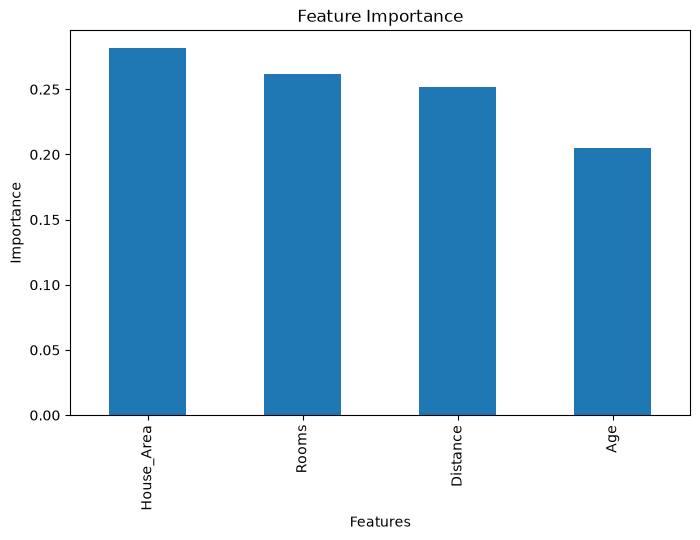

In [7]:
plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

## Interpretation

The Random Forest model assigns an importance value to each feature.

Features with higher importance contributed more to the model's predictions according to the model's impurity-based importance measure.

Feature importance does not mean that the feature causes the target to change.

For more robust interpretation, permutation importance or model-specific explanation methods can also be considered.

## Advantages

- Helps understand which features the model uses.
- Can support feature selection.
- Useful for model interpretation.
- Helps reduce unnecessary features in some workflows.

## Limitations

- Importance depends on the model and method.
- Correlated features can split importance between themselves.
- High importance does not imply causation.
- Impurity-based importance can be biased in some situations.

# Topic 5 – Feature Selection Basics

## Step 1 – Understand the Concept

Feature selection is the process of selecting a useful subset of features for a Machine Learning model.

The goal is to keep relevant information while reducing irrelevant or redundant features.

Feature selection can help:

- Reduce model complexity
- Reduce training time
- Improve interpretability
- Reduce redundant information
- Potentially improve generalization

Common approaches include:

### 1. Filter Methods

Features are selected using statistical properties.

Examples:

- Correlation
- Chi-Square
- Mutual Information

### 2. Wrapper Methods

Different feature subsets are evaluated using a Machine Learning model.

Example:

- Recursive Feature Elimination (RFE)

### 3. Embedded Methods

Feature selection occurs during model training.

Examples:

- Lasso Regression
- Tree-based feature importance

## Step 2 – Demonstrate the Concept

### Real-World Example

Suppose we predict house prices using 50 features.

Some features may be:

- Relevant
- Irrelevant
- Duplicated
- Highly correlated

Feature selection can help identify a smaller useful subset.

### Numerical Example

Suppose we have:

10 original features

After analysis:

6 useful features

4 unnecessary features

We can train the model using the selected features.

### Business Example

A bank predicts whether a customer will purchase a product.

It may have hundreds of customer attributes.

Feature selection can reduce the input variables to those that provide useful predictive information.

### AI/ML Example

Feature selection is commonly used before model training to reduce dimensionality and remove irrelevant or redundant predictors.

The selection process should be performed using the training data only to avoid data leakage.


## Step 3 – Implement the Concept

In [8]:
import pandas as pd
from sklearn.feature_selection import SelectKBest, f_regression

data = pd.DataFrame({
    "Study_Hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 95],
    "Sleep_Hours": [8, 7, 7, 6, 6, 5, 5, 4],
    "Random_Feature": [12, 3, 25, 7, 19, 2, 30, 11],
    "Marks": [45, 50, 58, 65, 72, 78, 85, 92]
})

X = data.drop("Marks", axis=1)
y = data["Marks"]

selector = SelectKBest(
    score_func=f_regression,
    k=2
)

X_selected = selector.fit_transform(X, y)

selected_features = X.columns[selector.get_support()]

print("Selected Features:")
print(selected_features.tolist())

Selected Features:
['Study_Hours', 'Attendance']


## Interpretation

SelectKBest evaluates each feature using the selected statistical scoring function.

In this example, f_regression is used because the target variable is numerical.

The two features with the highest scores are selected.

Feature selection should be performed carefully and within the training process to avoid data leakage.

The best feature-selection method depends on the problem, model, and data.

## Advantages

- Reduces the number of input features.
- Can reduce training time.
- Can improve interpretability.
- May reduce noise and redundancy.
- Useful for high-dimensional datasets.

## Limitations

- Removing a feature can remove useful information.
- Different selection methods may select different features.
- Feature selection can introduce bias if performed incorrectly.
- Selection must be done carefully to avoid data leakage.

# Interview Questions & Answers

## 1. What is a correlation matrix?

A correlation matrix is a table that shows the correlation coefficients between pairs of numerical variables.

The values usually range from -1 to +1.

---

## 2. What is multicollinearity?

Multicollinearity occurs when two or more predictor variables are highly related to each other.

It can make regression coefficients unstable and difficult to interpret.

---

## 3. What is VIF?

VIF stands for Variance Inflation Factor.

It measures how much the variance of an estimated regression coefficient is inflated because of relationships between predictors.

A VIF of 1 indicates no multicollinearity with the other predictors.

---

## 4. What is a commonly used VIF threshold?

There is no universal threshold.

A common rule of thumb is to investigate VIF values above 5 and pay particular attention to values above 10.

The appropriate interpretation depends on the context.

---

## 5. What is feature importance?

Feature importance describes how useful a feature is for a particular Machine Learning model according to a specific importance method.

Different models and importance techniques can produce different importance values.

---

## 6. Does high feature importance mean causation?

No.

Feature importance indicates predictive usefulness or contribution according to a model or method.

It does not prove that the feature causes the target variable to change.

---

## 7. What is feature selection?

Feature selection is the process of choosing a useful subset of features from the available features.

It can reduce complexity, redundancy, and computational cost.

---

## 8. What are the three main types of feature selection?

The three common categories are:

1. Filter methods
2. Wrapper methods
3. Embedded methods

---

## 9. What is the difference between feature selection and feature extraction?

Feature selection chooses existing features from the dataset.

Feature extraction creates new features by transforming or combining existing features.

For example, PCA is commonly considered a feature extraction/dimensionality-reduction technique.

---

## 10. Why is multicollinearity a problem in Linear Regression?

Multicollinearity can make coefficient estimates unstable and make it difficult to interpret the individual effect of each predictor.

The overall predictive performance may not necessarily be poor, but coefficient interpretation can become unreliable.

---

## 11. Can correlation be used for feature selection?

Yes.

Correlation can be used as a filter method to identify highly related features or features that have a relationship with a numerical target.

However, correlation alone should not be the only criterion for feature selection.

# Self Reflection

## What I Learned

I learned how to analyze relationships between features using a correlation matrix.

I understood what multicollinearity is and how VIF can be used to investigate it.

I also learned the difference between feature importance and feature selection.

## What I Practiced

I created a correlation matrix and visualization using Pandas and Matplotlib.

I calculated VIF using Statsmodels.

I used a Random Forest model to calculate feature importance.

I also practiced basic feature selection using SelectKBest.

## AI/ML Learning

I learned that feature relationships are important during Machine Learning preprocessing.

Highly correlated or redundant features can affect some models and make interpretation more difficult.

Feature selection can reduce the number of input variables and help create a simpler model.

## What I Need to Improve

I need more practice identifying multicollinearity in real-world datasets.

I also need to learn more feature-selection techniques such as RFE, Lasso, Mutual Information, and model-based selection.

I need to practice selecting features without causing data leakage.